# EXERCISE - Analysing objects in 3D
---

*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk)*

*Analysing objects in 3 dimensions*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

*Adapted from Tom Slater (slatert2@cardiff.ac.uk)*

*[Intro to building image analysis pipelines for 3D data with Python](https://github.com/RMS-DAIM/introduction-to-image-analysis/blob/main/Scripts/Jupyter/3d_analysis.ipynb)*

---

Fill in the gaps `[...]` in the notebook and look at the Tasks as you go through to achieve the 3D analysis. Solutions are available in the Scripts folder, but please give it a good try first! Also, try not to use ChatGPT or other LLMs (but Google is allowed!).

It might be helpful to use `napari` to visualise intermediate results as you go.

## Import libraries

In [59]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

import skimage
from skimage import filters
from skimage import data
from skimage import filters
from skimage import measure
from skimage import morphology
from skimage import segmentation
from skimage import feature
from skimage import io
import pandas as pd

import napari

import tqdm as notebook_tqdm

## Open image

We are going to use [a demo image from `skimage`](https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.cells3d), which contains 3 dimensions and 2 channels (membrane, ch0, and nuclei, ch1). For this exercise, we are going to subset the data to only keep the nuclear channel.

In [60]:
im_all = skimage.data.cells3d()

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Subset the image to only obtain the nuclear channel and load the result to a <code>napari</code> viewer window </div>

In [61]:
im_all.shape

(60, 2, 256, 256)

In [111]:
im_nuclei = im_all[:,1]
im_nuclei.shape

(60, 256, 256)

In [109]:
im_transpose = im_all.transpose(1,0,2,3)
im_transpose.shape

(2, 60, 256, 256)

In [110]:
viewer = napari.Viewer()
viewer.add_image(im_transpose[0,], name='membranes', colormap='magenta', blending='additive')
viewer.add_image(im_transpose[1,], name='nuclei', colormap='green', blending='additive')

<Image layer 'nuclei' at 0x227b90393f0>

In [112]:
viewer = napari.Viewer()
viewer.add_image(im_nuclei, name='nuclei', colormap='magenta')

<Image layer 'nuclei' at 0x227e3e015a0>

## Use filters to suppress noise

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Apply a Gaussian blur and load the result to a <code>napari</code> viewer window </div>

In [86]:
im_gauss = filters.gaussian(im_nuclei, sigma = 2)

In [87]:
viewer = napari.Viewer()
viewer.add_image(im_nuclei, name='nuclei', colormap='cyan', blending='additive')
viewer.add_image(im_gauss, name='nuclei_gauss', colormap='gray', blending='additive')

<Image layer 'nuclei_gauss' at 0x227b41e0d30>

## Segment volumes

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Segment the nuclei using one of <code>skimage</code> default algorithms and load the result to a <code>napari</code> viewer window </div>

In [89]:
im_gauss = filters.gaussian(im_nuclei, sigma = 2)
thresh = filters.threshold_otsu(im_gauss)
im_thresh = im_gauss >= thresh

labels = measure.label(im_thresh)

In [90]:
viewer.add_image(im_gauss, name='nuclei_gaussianfilter', blending='additive')
viewer.add_image(im_thresh, name='nuclei_binary', blending='additive')

<Image layer 'nuclei_binary' at 0x227cab7b250>

## Count objects

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Create a label image from the binary mask obtained in the step above and load the result to a <code>napari</code> viewer window. How many objects are there in the image? </div>

In [91]:
im_gauss = filters.gaussian(im_nuclei, sigma = 2)
thresh = filters.threshold_otsu(im_gauss)
im_thresh = im_gauss >= thresh

labels = measure.label(im_thresh)

In [92]:
labels = measure.label(im_thresh)
print('There are', labels.max(), 'objects in the image')

There are 23 objects in the image


In [93]:
viewer.add_labels(labels, blending = 'additive')

<Labels layer 'labels' at 0x227d454f910>

<div style="background-color:#c1c3d7; border-radius: 5px; padding: 10pt"><strong>Task (difficult!)</strong> We might be able to improve the quality of the segmentation with seeded watershedding. Give it a go and load the results to a <code>napari</code> viewer window. How many objects are there in the image, if we use this approach?</div>

In [ ]:
distance = ndi.distance_transform_edt(im_thresh)

# find local maxima
coords = skimage.feature.peak_local_max(distance, min_distance=20, labels=labels)

# create an empty image with the same shape as the input image
mask = np.zeros(im.shape, dtype=bool)

# add the markers as True pixels in the coordinates stored in coords (this is a binary mask!)
mask[tuple(coords.T)] = True

# label each True pixel (this is a label mask!)
markers = skimage.measure.label(mask)

# run seeded watershed
labels_watershed = segmentation.watershed(-distance, markers, mask=im_thresh)

# count the objects - find the maximum integer assigned to a label!
print('There are', labels_watershed.max(), 'objects in the image')

## Perform morphological quantification

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Measure the volume and locate the centroid of each nucleus. Save the results in a pandas dataframe and plot the distribution of volumes in a histogram. </div>

In [94]:
vol = im_nuclei
vol.shape

(60, 256, 256)

In [95]:
vol_gauss = filters.gaussian(vol, sigma = 1.5)

In [97]:
thresh = filters.threshold_otsu(vol_gauss)
vol_thresh = vol_gauss > thresh

In [99]:
labels = measure. label (vol_thresh)
print('There are', labels.max(), 'objects in the image')

There are 24 objects in the image


In [100]:
viewer = napari. Viewer ()
viewer. add_labels(labels, blending='additive')

<Labels layer 'labels' at 0x227d8994d00>

In [114]:
props = skimage.measure.regionprops_table(labels, properties=['label', 'area', 'centroid'])
props_df = pd.DataFrame (props)

props_df.head()

,label,area,centroid-0,centroid-1,centroid-2
0,1,36063.0,39.573690,87.181821,53.510163
1,2,23375.0,33.477048,219.708321,244.578567
2,3,184756.0,34.466366,195.316136,75.879219
3,4,42773.0,34.322844,157.452295,110.799266
4,5,49258.0,31.471030,201.475314,173.571460


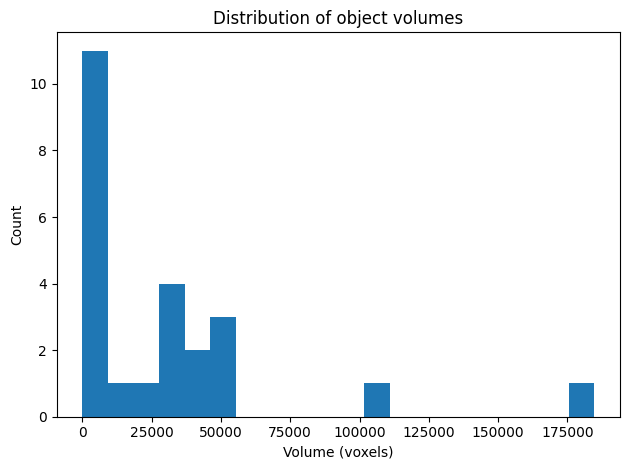

In [113]:
regions = skimage.measure.regionprops(labels)
volumes = [region.area for region in regions]

plt.hist(volumes, bins=20)
plt.xlabel('Volume (voxels)')
plt.ylabel('Count')
plt.title('Distribution of object volumes')
plt.tight_layout()